In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results__.html
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__notebook__.ipynb
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__output__.json
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/custom.css
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results___files/__results___18_1.png
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results___files/__results___18_4.png
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results___files/__results___31_0.png
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results___files/__results___24_0.png
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results___files/__results___35_0.png
/kaggle/input/notebooks/phyothaw/07-exploratory-data-analysis-ipynb/__results___files/__results___18_2.png
/kaggle/input/notebooks

# Notebook 08: Baseline and Stock-Specific Machine Learning Models

## Objective

This notebook develops baseline machine-learning models for predicting
five-trading-day stock movement for each individual stock.

Each stock is modelled independently using a fixed-year temporal split,
where models are trained on data from 2020–2024 and evaluated on
previously unseen data from 2025.

The evaluated baseline models are:

- Dummy Classifier
- Logistic Regression (L2)
- Random Forest
- XGBoost

The resulting predictions and probabilities will be used in later
notebooks for pooled modelling, cross-stock generalisation, calibration,
and explanation stability analysis.

**RQ1: How accurately can machine learning models predict 5-day stock movement for each individual stock?**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import seaborn as sb

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
data_df = pd.read_csv("/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv")

In [4]:
data_df.shape

(7370, 42)

In [5]:
data_df.head()

,ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_50,SMA_200,EMA_50,EMA_200,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,ADX,date,gdelt_company_tone,gdelt_tone_missing,gdelt_tone_lag_1,gdelt_tone_mean_3,gdelt_tone_mean_5,gdelt_tone_std_5,gdelt_tone_change_1d,gdelt_abnormal_tone_20,market_close,market_return,vix_close,vix_change,market_return_lag_1,vix_close_lag_1,vix_change_lag_1,daily_return_check,future_close_5d,forward_return_5d,movement_5d,target_5d
0,BRK-B,227.0500,228.4700,226.1300,228.4500,3286700,0.0000,0.0000,222.4416,210.6961,222.0380,212.6147,60.9110,1.6414,1.7916,-0.1502,228.5025,226.4395,224.3765,2.0712,24.1401,2020-01-13,0.1082,0,1.0689,0.3863,0.3871,0.4659,0.7778,0.4865,3288.1299,0.0070,12.3200,-0.0191,-0.0029,12.5600,0.0016,0.0081,228.6300,0.0008,Neutral,1
1,BRK-B,227.8500,228.3900,226.8800,227.1700,3355400,0.0000,0.0000,222.7334,210.8275,222.2392,212.7595,56.3503,1.5518,1.7436,-0.1919,228.5548,226.5295,224.5042,2.0354,23.7312,2020-01-14,0.6846,0,0.1082,0.4894,0.3000,0.4700,-0.9607,-0.5147,3283.1499,-0.0015,12.3900,0.0057,0.0070,12.3200,-0.0191,-0.0056,229.5400,0.0104,Neutral,1
2,BRK-B,226.8000,228.6400,226.7800,228.3500,2662500,0.0000,0.0000,222.9838,210.9442,222.4789,212.9146,59.3705,1.5580,1.7065,-0.1485,228.7774,226.6045,224.4316,2.0229,23.4895,2020-01-15,-0.9342,0,0.6846,0.6206,0.3903,0.4966,0.5764,0.1013,3289.2900,0.0019,12.4200,0.0024,-0.0015,12.3900,0.0057,0.0052,229.3800,0.0045,Neutral,1
3,BRK-B,229.3400,230.0300,228.5200,229.7300,3036400,0.0000,0.0000,223.2188,211.0735,222.7632,213.0819,62.6272,1.6552,1.6962,-0.0411,229.3005,226.7385,224.1765,1.9984,23.9712,2020-01-16,1.1183,0,-0.9342,-0.0471,0.2437,0.7555,-1.6188,-1.5248,3316.8101,0.0084,12.3200,-0.0081,0.0019,12.4200,0.0024,0.0060,226.8600,-0.0125,Neutral,1
4,BRK-B,230.1300,231.6100,229.5500,230.2000,6603800,0.0000,0.0000,223.4052,211.2061,223.0549,213.2523,63.6946,1.7500,1.7070,0.0430,229.8428,226.9980,224.1531,2.0028,25.0760,2020-01-17,1.3977,0,1.1183,0.2896,0.4092,0.8528,2.0525,0.6294,3329.6201,0.0039,12.1000,-0.0179,0.0084,12.3200,-0.0081,0.0020,222.4500,-0.0337,Down,0


In [6]:
print("="*60)
print("Dataset Information")
print("="*60)

print(f"Rows    : {data_df.shape[0]:,}")
print(f"Columns : {data_df.shape[1]:,}")

print("\nDate Range")
print(f"Start Date : {data_df['date'].min()}")
print(f"End Date   : {data_df['date'].max()}")

print("\nStock Distribution")
display(
    data_df["ticker"]
    .value_counts()
    .sort_index()
    .to_frame("Observations")
)

print("\nMissing Values")
missing = (
    data_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="Missing Count")
)
display(missing[missing["Missing Count"] > 0])

Dataset Information
Rows    : 7,370
Columns : 42

Date Range
Start Date : 2020-01-13
End Date   : 2025-12-22

Stock Distribution


,Observations
ticker,
BRK-B,1474
CVX,1474
GE,1474
MSFT,1474
NVDA,1474



Missing Values


,Missing Count
gdelt_company_tone,10


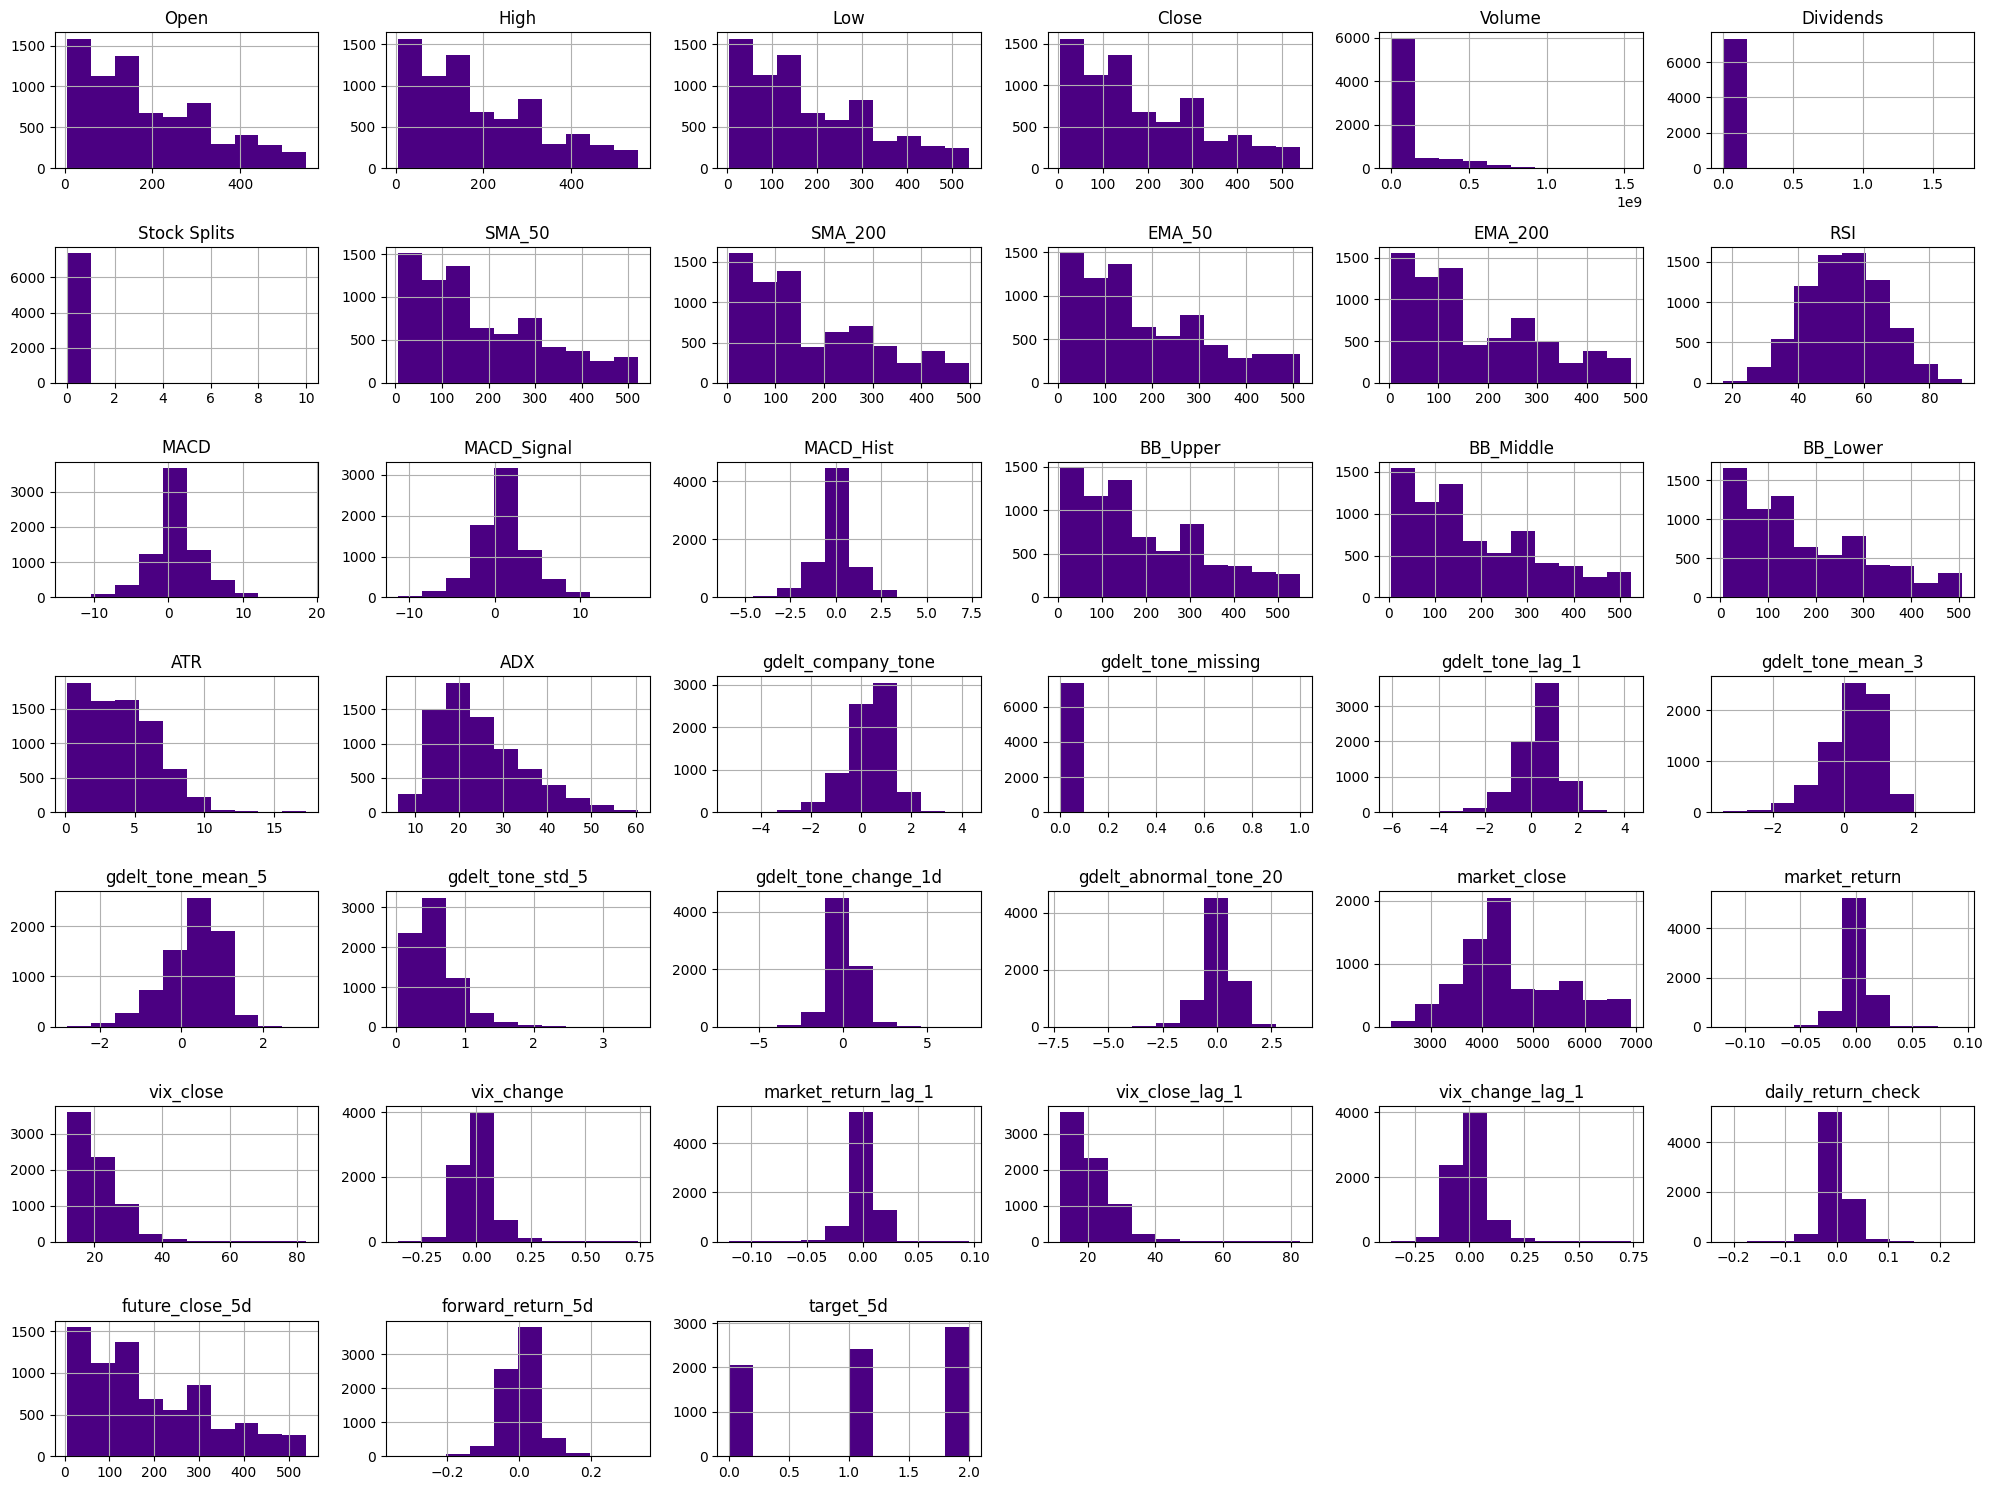

In [7]:
data_df.hist(figsize=(20,15), bins=10, color='indigo')
plt.tight_layout()
plt.show()

In [8]:
data_df["gdelt_tone_missing"] = (
    data_df["gdelt_company_tone"].isna().astype(int)
)

data_df["gdelt_company_tone"] = (
    data_df["gdelt_company_tone"].fillna(0)
)

print("Missing values after GDELT tone handling:")
missing = (
    data_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="Missing Count")
)
display(missing[missing["Missing Count"] > 0])

Missing values after GDELT tone handling:


,Missing Count


In [9]:
print("\nMissing Values")
missing = (data_df.isna().sum().sort_values(ascending=False).to_frame(name="Missing Count"))

display(missing)

print("\nStock Distribution")
stock_distribution = (data_df["ticker"].value_counts().sort_index().to_frame(name="Observations"))

display(stock_distribution)


Missing Values


,Missing Count
ticker,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0
SMA_50,0
SMA_200,0



Stock Distribution


,Observations
ticker,
BRK-B,1474
CVX,1474
GE,1474
MSFT,1474
NVDA,1474


In [10]:
# ==========================================================
# Feature Selection
# ==========================================================

TARGET = "target_5d"

DROP_COLUMNS = [
    # Identifiers
    "ticker",
    "date",

    # Future information / data leakage
    "future_close_5d",
    "forward_return_5d",

    # Target variables
    "movement_5d",
    "target_5d",

    # Low-information features
    "Dividends",
    "Stock Splits"
]

FEATURE_COLUMNS = [
    column
    for column in data_df.columns
    if column not in DROP_COLUMNS
]

print("=" * 60)
print("Feature Selection")
print("=" * 60)
print(f"Total Columns      : {data_df.shape[1]}")
print(f"Dropped Columns    : {len(DROP_COLUMNS)}")
print(f"Predictor Features : {len(FEATURE_COLUMNS)}")

print("\nDropped Columns")
print(DROP_COLUMNS)

print("\nPredictor Features")
display(pd.DataFrame(FEATURE_COLUMNS, columns=["Feature"]))

Feature Selection
Total Columns      : 42
Dropped Columns    : 8
Predictor Features : 34

Dropped Columns
['ticker', 'date', 'future_close_5d', 'forward_return_5d', 'movement_5d', 'target_5d', 'Dividends', 'Stock Splits']

Predictor Features


,Feature
0,Open
1,High
2,Low
3,Close
4,Volume
5,SMA_50
6,SMA_200
7,EMA_50
8,EMA_200
9,RSI


## Temporal Train-Test Split

A fixed-year temporal split is used throughout the study:

- **Training:** 2020–2024
- **Testing:** 2025

Each stock is modelled separately. The models are trained only on observations available before the test year.

In [11]:
# Experiment Configuration
TEST_YEAR = 2025
RANDOM_STATE = 42

stocks = sorted(data_df["ticker"].unique())

print("=" * 60)
print("Experiment Configuration")
print("=" * 60)
print(f"Target Variable : {TARGET}")
print(f"Test Year       : {TEST_YEAR}")
print(f"Random State    : {RANDOM_STATE}")
print(f"Number of Stocks: {len(stocks)}")
print(f"Stocks          : {stocks}")

Experiment Configuration
Target Variable : target_5d
Test Year       : 2025
Random State    : 42
Number of Stocks: 5
Stocks          : ['BRK-B', 'CVX', 'GE', 'MSFT', 'NVDA']


In [12]:
data_df.columns.tolist()

['ticker',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Dividends',
 'Stock Splits',
 'SMA_50',
 'SMA_200',
 'EMA_50',
 'EMA_200',
 'RSI',
 'MACD',
 'MACD_Signal',
 'MACD_Hist',
 'BB_Upper',
 'BB_Middle',
 'BB_Lower',
 'ATR',
 'ADX',
 'date',
 'gdelt_company_tone',
 'gdelt_tone_missing',
 'gdelt_tone_lag_1',
 'gdelt_tone_mean_3',
 'gdelt_tone_mean_5',
 'gdelt_tone_std_5',
 'gdelt_tone_change_1d',
 'gdelt_abnormal_tone_20',
 'market_close',
 'market_return',
 'vix_close',
 'vix_change',
 'market_return_lag_1',
 'vix_close_lag_1',
 'vix_change_lag_1',
 'daily_return_check',
 'future_close_5d',
 'forward_return_5d',
 'movement_5d',
 'target_5d']

## Stock-Specific Baseline Models

For each stock, the same four models are trained and evaluated independently:

1. Dummy Classifier
2. Random Forest
3. XGBoost
4. Logistic Regression

Logistic Regression is placed last because it requires standardized features.

In [13]:
data_df["date"] = pd.to_datetime(data_df["date"])

print(data_df["date"].dtype)

datetime64[ns]


In [14]:
# ==========================================================
# Prepare Stock-Specific Train/Test Data
# ==========================================================

stock_data = {}

for stock in stocks:

    stock_df = data_df[data_df["ticker"] == stock].copy()

    # Train set
    train_df = stock_df[
        stock_df["date"].dt.year < TEST_YEAR
    ].copy()

    # Test set
    test_df = stock_df[
        stock_df["date"].dt.year == TEST_YEAR
    ].copy()

    # Features
    x_train = train_df[FEATURE_COLUMNS]
    y_train = train_df[TARGET]

    x_test = test_df[FEATURE_COLUMNS]
    y_test = test_df[TARGET]

    stock_data[stock] = {
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test,
        "test_dates": test_df["date"].values
    }

    print(f"{stock}")
    print(f"Training samples : {len(train_df)}")
    print(f"Testing samples  : {len(test_df)}")
    print("-" * 40)

BRK-B
Training samples : 1248
Testing samples  : 226
----------------------------------------
CVX
Training samples : 1248
Testing samples  : 226
----------------------------------------
GE
Training samples : 1248
Testing samples  : 226
----------------------------------------
MSFT
Training samples : 1248
Testing samples  : 226
----------------------------------------
NVDA
Training samples : 1248
Testing samples  : 226
----------------------------------------


In [15]:
print(data_df["date"].dtype)
print(data_df["date"].head())

datetime64[ns]
0   2020-01-13
1   2020-01-14
2   2020-01-15
3   2020-01-16
4   2020-01-17
Name: date, dtype: datetime64[ns]


In [16]:
print(f"Training samples : {len(train_df)}")
print(f"Testing samples  : {len(test_df)}")

Training samples : 1248
Testing samples  : 226


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, ConfusionMatrixDisplay

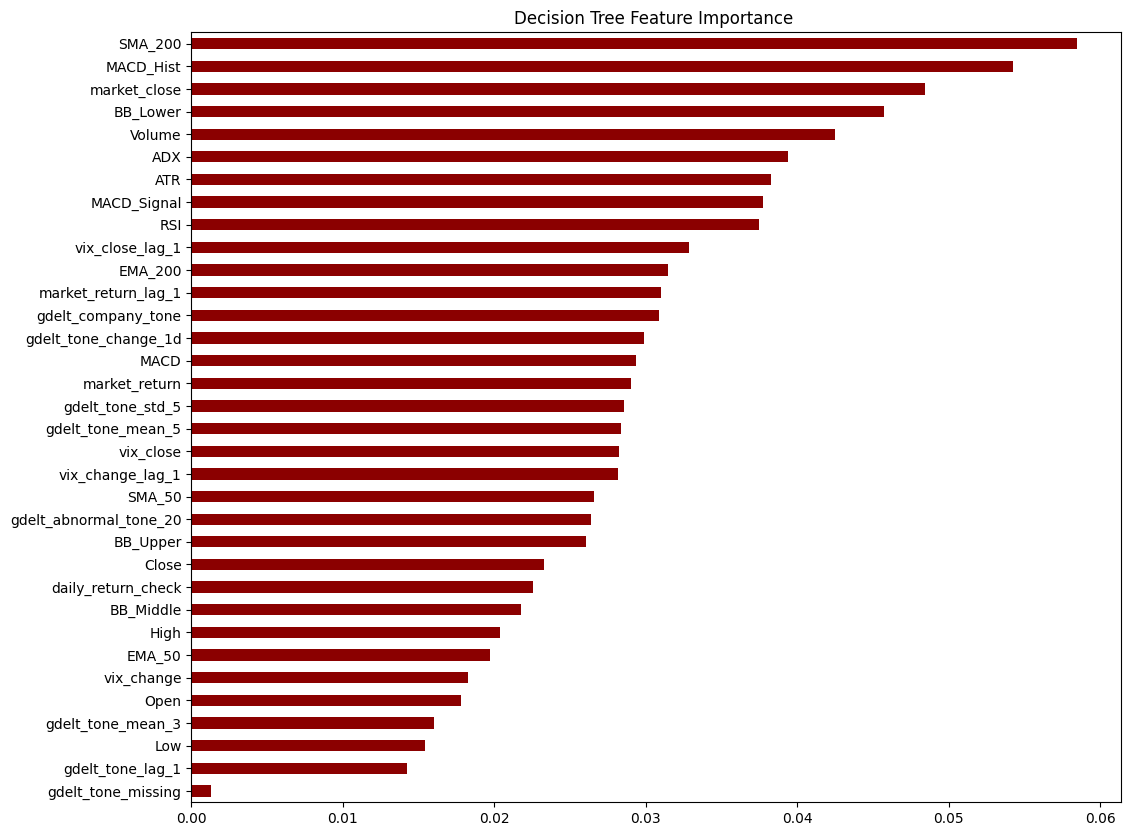

In [18]:

# Combine training data from all stocks

x_train_all = pd.concat([stock_data[stock]["x_train"] for stock in stocks],axis=0)
y_train_all = pd.concat([stock_data[stock]["y_train"] for stock in stocks],axis=0)

# Train one Decision Tree

dt_imp = DecisionTreeClassifier(criterion="gini",splitter="best",max_depth=None,min_samples_split=2,min_samples_leaf=1,random_state=42)
dt_imp.fit(x_train_all, y_train_all)

# Feature importance

importances = dt_imp.feature_importances_
importances_df = pd.Series(importances,index=x_train_all.columns).sort_values()

# Plot

importances_df.plot(kind="barh",color="darkred",title="Decision Tree Feature Importance ",figsize=(12, 10))
plt.show()

**Dummy Classifier**

Dummy Classifier - NVDA
Accuracy            : 0.4558
Balanced Accuracy   : 0.3333
Precision (Weighted): 0.2077
Recall (Weighted)   : 0.4558
F1 Score (Weighted) : 0.2854
ROC-AUC (OvR)       : 0.5000


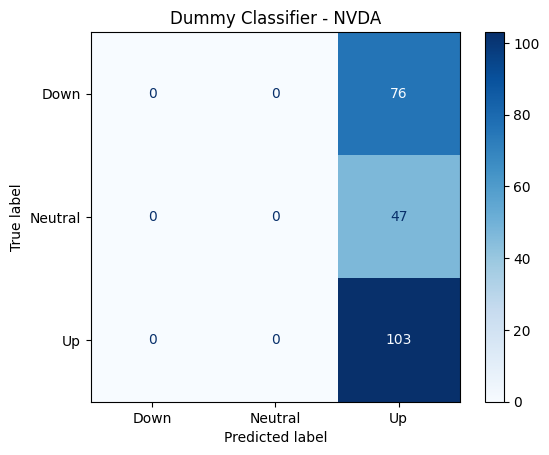


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        76
     Neutral       0.00      0.00      0.00        47
          Up       0.46      1.00      0.63       103

    accuracy                           0.46       226
   macro avg       0.15      0.33      0.21       226
weighted avg       0.21      0.46      0.29       226



In [19]:
    dummy_model = DummyClassifier(strategy="most_frequent")
    dummy_model.fit(x_train, y_train)
    dummy_pred = dummy_model.predict(x_test)
    dummy_prob = dummy_model.predict_proba(x_test)

    accuracy = accuracy_score(y_test, dummy_pred)
    balanced_accuracy = balanced_accuracy_score(y_test,dummy_pred)
    precision = precision_score(y_test, dummy_pred, average="weighted",zero_division=0)
    recall = recall_score(y_test,dummy_pred,average="weighted",zero_division=0)
    f1 = f1_score(y_test,dummy_pred,average="weighted",zero_division=0)
    roc_auc = roc_auc_score(y_test,dummy_prob,multi_class="ovr")
    
    print("=" * 60)
    print(f"Dummy Classifier - {stock}")
    print("=" * 60)
    
    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_accuracy:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted)   : {recall:.4f}")
    print(f"F1 Score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        dummy_pred,
        display_labels=["Down", "Neutral", "Up"],
        cmap="Blues"
    )
    
    plt.title(f"Dummy Classifier - {stock}")
    plt.show()
    
    print("\nClassification Report")
    
    print(
        classification_report(
            y_test,
            dummy_pred,
            labels=[0, 1, 2],
            target_names=["Down", "Neutral", "Up"],
            zero_division=0))

Random Forest - NVDA
Accuracy            : 0.4248
Balanced Accuracy   : 0.3601
Precision (Weighted): 0.3721
Recall (Weighted)   : 0.4248
F1 Score (Weighted) : 0.3868
ROC-AUC (OvR)       : 0.5975


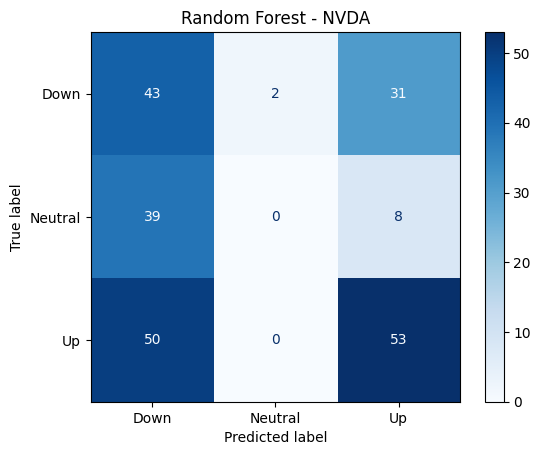


Classification Report
              precision    recall  f1-score   support

        Down       0.33      0.57      0.41        76
     Neutral       0.00      0.00      0.00        47
          Up       0.58      0.51      0.54       103

    accuracy                           0.42       226
   macro avg       0.30      0.36      0.32       226
weighted avg       0.37      0.42      0.39       226



In [20]:
    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1)
    
    rf_model.fit(x_train, y_train)
    rf_pred = rf_model.predict(x_test)
    rf_prob = rf_model.predict_proba(x_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, rf_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)
    precision = precision_score(y_test, rf_pred,average="weighted",zero_division=0)
    
    recall = recall_score(y_test, rf_pred,average="weighted",zero_division=0)
    f1 = f1_score(y_test, rf_pred,average="weighted",zero_division=0)
    roc_auc = roc_auc_score(y_test,rf_prob,multi_class="ovr")
    
    print("=" * 60)
    print(f"Random Forest - {stock}")
    print("=" * 60)
    
    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_accuracy:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted)   : {recall:.4f}")
    print(f"F1 Score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        rf_pred,
        display_labels=["Down", "Neutral", "Up"],
        cmap="Blues")
    
    plt.title(f"Random Forest - {stock}")
    plt.show()
    
    # Classification Report
    print("\nClassification Report")
    
    print(
        classification_report(
            y_test,
            rf_pred,
            labels=[0, 1, 2],
            target_names=["Down", "Neutral", "Up"],
            zero_division=0))

XGBoost - NVDA
Accuracy            : 0.4159
Balanced Accuracy   : 0.3525
Precision (Weighted): 0.3626
Recall (Weighted)   : 0.4159
F1 Score (Weighted) : 0.3783
ROC-AUC (OvR)       : 0.5818


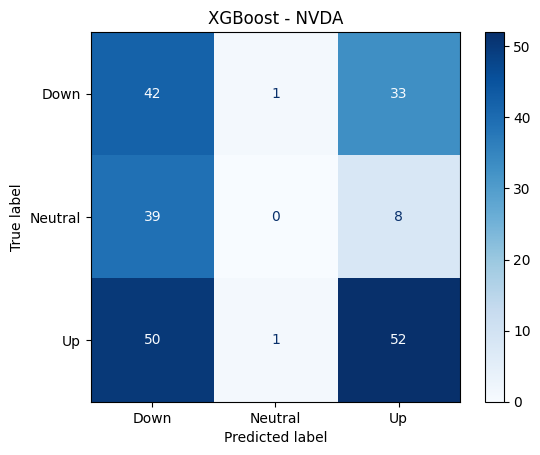


Classification Report
              precision    recall  f1-score   support

        Down       0.32      0.55      0.41        76
     Neutral       0.00      0.00      0.00        47
          Up       0.56      0.50      0.53       103

    accuracy                           0.42       226
   macro avg       0.29      0.35      0.31       226
weighted avg       0.36      0.42      0.38       226



In [21]:
    xgb_model = XGBClassifier(n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
    
    xgb_model.fit(x_train, y_train)
    xgb_pred = xgb_model.predict(x_test)
    xgb_prob = xgb_model.predict_proba(x_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, xgb_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, xgb_pred)
    precision = precision_score(y_test, xgb_pred,average="weighted",zero_division=0)
    
    recall = recall_score(y_test, xgb_pred,average="weighted",zero_division=0)
    f1 = f1_score(y_test, xgb_pred,average="weighted",zero_division=0)
    roc_auc = roc_auc_score(y_test,xgb_prob,multi_class="ovr")
    
    print("=" * 60)
    print(f"XGBoost - {stock}")
    print("=" * 60)
    
    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_accuracy:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted)   : {recall:.4f}")
    print(f"F1 Score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        xgb_pred,
        display_labels=["Down", "Neutral", "Up"],
        cmap="Blues"
    )
    
    plt.title(f"XGBoost - {stock}")
    plt.show()
    
    # Classification Report
    print("\nClassification Report")
    
    print(
        classification_report(
            y_test,
            xgb_pred,
            labels=[0, 1, 2],
            target_names=["Down", "Neutral", "Up"],
            zero_division=0
        )
    )

Logistic Regression - NVDA
Accuracy            : 0.4469
Balanced Accuracy   : 0.3349
Precision (Weighted): 0.3025
Recall (Weighted)   : 0.4469
F1 Score (Weighted) : 0.3294
ROC-AUC (OvR)       : 0.4829


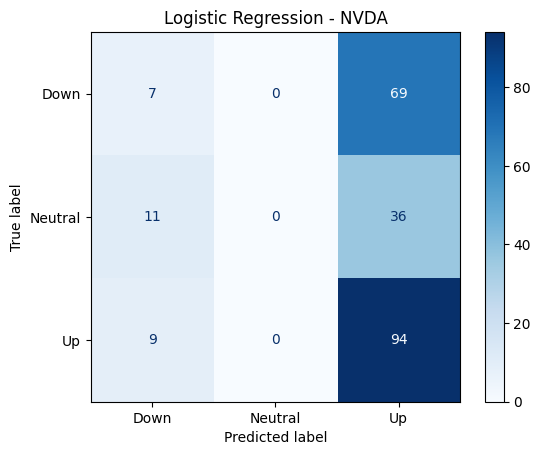


Classification Report
              precision    recall  f1-score   support

        Down       0.26      0.09      0.14        76
     Neutral       0.00      0.00      0.00        47
          Up       0.47      0.91      0.62       103

    accuracy                           0.45       226
   macro avg       0.24      0.33      0.25       226
weighted avg       0.30      0.45      0.33       226



In [22]:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    
    lr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])
    
    lr_model.fit(x_train, y_train)
    
    lr_pred = lr_model.predict(x_test)
    lr_prob = lr_model.predict_proba(x_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, lr_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, lr_pred)
    precision = precision_score(
        y_test, lr_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test, lr_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test, lr_pred,
        average="weighted",
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        lr_prob,
        multi_class="ovr"
    )
    
    print("=" * 60)
    print(f"Logistic Regression - {stock}")
    print("=" * 60)
    
    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_accuracy:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted)   : {recall:.4f}")
    print(f"F1 Score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        lr_pred,
        display_labels=["Down", "Neutral", "Up"],
        cmap="Blues"
    )
    
    plt.title(f"Logistic Regression - {stock}")
    plt.show()
    
    # Classification Report
    print("\nClassification Report")
    
    print(
        classification_report(
            y_test,
            lr_pred,
            labels=[0, 1, 2],
            target_names=["Down", "Neutral", "Up"],
            zero_division=0
        )
    )

# Part B LSTM model

In [23]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
print("GPU available:", tf.config.list_physical_devices("GPU"))

GPU available: []


2026-08-08 20:53:22.973037: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [25]:
    # ==========================================================
    # Prepare LSTM Sequences
    # ==========================================================
    
    lookback = 30
    
    scaler_lstm = StandardScaler()
    
    x_train_scaled = scaler_lstm.fit_transform(x_train)
    x_test_scaled = scaler_lstm.transform(x_test)
    
    # Convert to DataFrame to preserve the feature structure
    x_train_scaled = pd.DataFrame(
        x_train_scaled,
        columns=x_train.columns,
        index=x_train.index
    )
    
    x_test_scaled = pd.DataFrame(
        x_test_scaled,
        columns=x_test.columns,
        index=x_test.index
    )
    
    # Combine the last training observations with test observations
    # so that the first test sequence has historical context.
    x_test_context = pd.concat([
        x_train_scaled.tail(lookback),
        x_test_scaled
    ])
    
    y_test_context = pd.concat([
        y_train.tail(lookback),
        y_test
    ])
    
    # ----------------------------------------------------------
    # Create training sequences
    # ----------------------------------------------------------
    
    x_train_seq = []
    y_train_seq = []
    
    for i in range(lookback, len(x_train_scaled)):
    
        x_train_seq.append(
            x_train_scaled.iloc[i-lookback:i].values
        )
    
        y_train_seq.append(
            y_train.iloc[i]
        )
    
    # ----------------------------------------------------------
    # Create test sequences
    # ----------------------------------------------------------
    
    x_test_seq = []
    y_test_seq = []
    
    for i in range(lookback, len(x_test_context)):
    
        x_test_seq.append(
            x_test_context.iloc[i-lookback:i].values
        )
    
        y_test_seq.append(
            y_test_context.iloc[i]
        )
    
    x_train_seq = np.array(x_train_seq)
    y_train_seq = np.array(y_train_seq)
    
    x_test_seq = np.array(x_test_seq)
    y_test_seq = np.array(y_test_seq)
    
    print("Training sequence shape:", x_train_seq.shape)
    print("Testing sequence shape :", x_test_seq.shape)

Training sequence shape: (1218, 30, 34)
Testing sequence shape : (226, 30, 34)


In [26]:
    # ==========================================================
    # Build LSTM Model
    # ==========================================================
    
    lstm_model = Sequential([
        LSTM(64,input_shape=(x_train_seq.shape[1], x_train_seq.shape[2])),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(3, activation="softmax")
    ])
    
    lstm_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        25,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,523 (107.51 KB)

 Trainable params: 27,523 (107.51 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
    # ==========================================================
    # Train LSTM
    # ==========================================================
    
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
    
    lstm_history = lstm_model.fit(
        x_train_seq,
        y_train_seq,
        epochs=50,
        batch_size=32,
        validation_split=0.15,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4638 - loss: 1.0425 - val_accuracy: 0.4918 - val_loss: 1.0582
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4957 - loss: 1.0103 - val_accuracy: 0.5683 - val_loss: 1.0067
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5391 - loss: 0.9808 - val_accuracy: 0.5847 - val_loss: 0.9901
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5469 - loss: 0.9607 - val_accuracy: 0.6284 - val_loss: 0.9688
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5729 - loss: 0.9276 - val_accuracy: 0.6175 - val_loss: 0.9690
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5662 - loss: 0.9297 - val_accuracy: 0.5410 - val_loss: 0.9695
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6010 - loss: 0.8931 - val_accuracy: 0.5628 - val_loss: 0.9612
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5894 - loss: 0.9039 - val_accuracy: 0.3989 - v

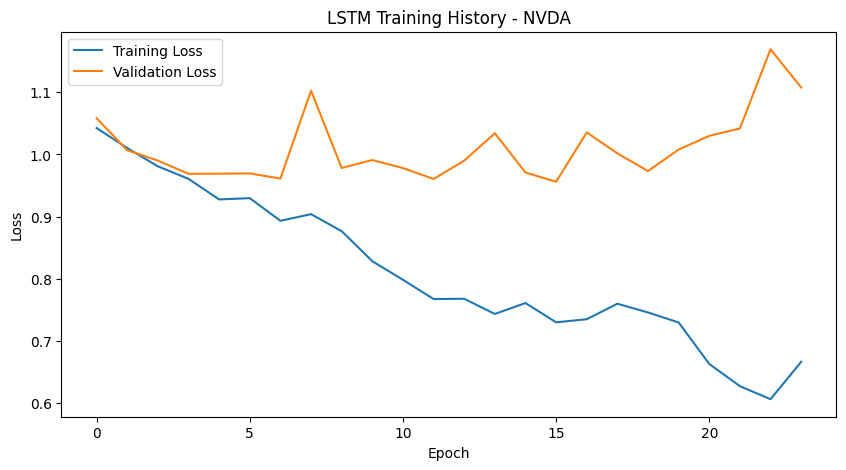

In [28]:
    # ==========================================================
    # LSTM Training History
    # ==========================================================
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(
        lstm_history.history["loss"],
        label="Training Loss"
    )
    
    plt.plot(
        lstm_history.history["val_loss"],
        label="Validation Loss"
    )
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"LSTM Training History - {stock}")
    
    plt.legend()
    plt.show()

In [29]:
    # ==========================================================
    # LSTM Evaluation
    # ==========================================================
    
    lstm_prob = lstm_model.predict(
        x_test_seq,
        verbose=0
    )
    
    lstm_pred = np.argmax(
        lstm_prob,
        axis=1
    )
    
    accuracy = accuracy_score(
        y_test_seq,
        lstm_pred
    )
    
    balanced_accuracy = balanced_accuracy_score(
        y_test_seq,
        lstm_pred
    )
    
    precision = precision_score(
        y_test_seq,
        lstm_pred,
        average="weighted",
        zero_division=0
    )
    
    recall = recall_score(
        y_test_seq,
        lstm_pred,
        average="weighted",
        zero_division=0
    )
    
    f1 = f1_score(
        y_test_seq,
        lstm_pred,
        average="weighted",
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_test_seq,
        lstm_prob,
        multi_class="ovr"
    )
    
    print("=" * 60)
    print(f"LSTM - {stock}")
    print("=" * 60)
    
    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_accuracy:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted)   : {recall:.4f}")
    print(f"F1 Score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")

LSTM - NVDA
Accuracy            : 0.4159
Balanced Accuracy   : 0.3295
Precision (Weighted): 0.3186
Recall (Weighted)   : 0.4159
F1 Score (Weighted) : 0.3598
ROC-AUC (OvR)       : 0.5080


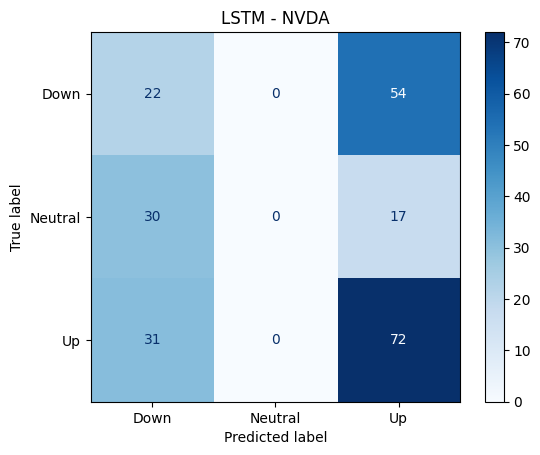


Classification Report
              precision    recall  f1-score   support

        Down       0.27      0.29      0.28        76
     Neutral       0.00      0.00      0.00        47
          Up       0.50      0.70      0.59       103

    accuracy                           0.42       226
   macro avg       0.26      0.33      0.29       226
weighted avg       0.32      0.42      0.36       226



In [30]:
    # ==========================================================
    # LSTM Confusion Matrix
    # ==========================================================
    
    ConfusionMatrixDisplay.from_predictions(
        y_test_seq,
        lstm_pred,
        display_labels=["Down", "Neutral", "Up"],
        cmap="Blues"
    )
    
    plt.title(f"LSTM - {stock}")
    plt.show()
    print("\nClassification Report")

    print(
        classification_report(
            y_test_seq,
            lstm_pred,
            labels=[0, 1, 2],
            target_names=["Down", "Neutral", "Up"],
            zero_division=0
        )
    )

In [31]:
    lstm_predictions = pd.DataFrame({
        "ticker": stock,
        "model": "LSTM",
        "actual": y_test_seq,
        "predicted": lstm_pred,
        "prob_down": lstm_prob[:, 0],
        "prob_neutral": lstm_prob[:, 1],
        "prob_up": lstm_prob[:, 2]
    })

In [32]:
    # ==========================================================
    # Store Results for All Five Models
    # ==========================================================
    
    dummy_result = {
        "model": "Dummy",
        "accuracy": accuracy_score(y_test, dummy_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, dummy_pred),
        "precision_weighted": precision_score(
            y_test, dummy_pred,
            average="weighted",
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_test, dummy_pred,
            average="weighted",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_test, dummy_pred,
            average="weighted",
            zero_division=0
        ),
        "roc_auc_ovr": roc_auc_score(
            y_test,
            dummy_prob,
            multi_class="ovr"
        )
    }
    
    
    rf_result = {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, rf_pred),
        "precision_weighted": precision_score(
            y_test, rf_pred,
            average="weighted",
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_test, rf_pred,
            average="weighted",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_test, rf_pred,
            average="weighted",
            zero_division=0
        ),
        "roc_auc_ovr": roc_auc_score(
            y_test,
            rf_prob,
            multi_class="ovr"
        )
    }
    
    
    xgb_result = {
        "model": "XGBoost",
        "accuracy": accuracy_score(y_test, xgb_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, xgb_pred),
        "precision_weighted": precision_score(
            y_test, xgb_pred,
            average="weighted",
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_test, xgb_pred,
            average="weighted",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_test, xgb_pred,
            average="weighted",
            zero_division=0
        ),
        "roc_auc_ovr": roc_auc_score(
            y_test,
            xgb_prob,
            multi_class="ovr"
        )
    }
    
    
    lr_result = {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, lr_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, lr_pred),
        "precision_weighted": precision_score(
            y_test, lr_pred,
            average="weighted",
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_test, lr_pred,
            average="weighted",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_test, lr_pred,
            average="weighted",
            zero_division=0
        ),
        "roc_auc_ovr": roc_auc_score(
            y_test,
            lr_prob,
            multi_class="ovr"
        )
    }
    
    
    lstm_result = {
        "model": "LSTM",
        "accuracy": accuracy_score(y_test_seq, lstm_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_test_seq, lstm_pred
        ),
        "precision_weighted": precision_score(
            y_test_seq, lstm_pred,
            average="weighted",
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_test_seq, lstm_pred,
            average="weighted",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_test_seq, lstm_pred,
            average="weighted",
            zero_division=0
        ),
        "roc_auc_ovr": roc_auc_score(
            y_test_seq,
            lstm_prob,
            multi_class="ovr"
        )
    }

In [33]:
print("Dummy: ", dummy_pred.shape)
print("RF", rf_pred.shape)
print("XGB", xgb_pred.shape)
print("LR", lr_pred.shape)
print("LSTM", lstm_pred.shape)

Dummy:  (226,)
RF (226,)
XGB (226,)
LR (226,)
LSTM (226,)


In [34]:
# ==========================================================
# Compare All Five Models
# ==========================================================

results_df = pd.DataFrame([
    dummy_result,
    rf_result,
    xgb_result,
    lr_result,
    lstm_result
])

display(results_df)

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,Dummy,0.4558,0.3333,0.2077,0.4558,0.2854,0.5000
1,Random Forest,0.4248,0.3601,0.3721,0.4248,0.3868,0.5975
2,XGBoost,0.4159,0.3525,0.3626,0.4159,0.3783,0.5818
3,Logistic Regression,0.4469,0.3349,0.3025,0.4469,0.3294,0.4829
4,LSTM,0.4159,0.3295,0.3186,0.4159,0.3598,0.5080


In [35]:
# ==========================================================
# Highlight Best Model
# ==========================================================

best_index = results_df["balanced_accuracy"].idxmax()

def highlight_best(row):
    if row.name == best_index:
        return ["background-color: lightgreen"] * len(row)

    return [""] * len(row)

display(
    results_df.style
    .apply(highlight_best, axis=1)
    .format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "precision_weighted": "{:.4f}",
        "recall_weighted": "{:.4f}",
        "f1_weighted": "{:.4f}",
        "roc_auc_ovr": "{:.4f}"
    })
)

print(
    f"Best model based on Balanced Accuracy: "
    f"{results_df.loc[best_index, 'model']}"
)

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,Dummy,0.4558,0.3333,0.2077,0.4558,0.2854,0.5000
1,Random Forest,0.4248,0.3601,0.3721,0.4248,0.3868,0.5975
2,XGBoost,0.4159,0.3525,0.3626,0.4159,0.3783,0.5818
3,Logistic Regression,0.4469,0.3349,0.3025,0.4469,0.3294,0.4829
4,LSTM,0.4159,0.3295,0.3186,0.4159,0.3598,0.5080


Best model based on Balanced Accuracy: Random Forest


### Preliminary Model Comparison — NVDA

The first LSTM experiment was conducted with GPU acceleration enabled. The model was trained using a 30-trading-day lookback window and early stopping.

| Model | Accuracy | Balanced Accuracy | Precision (Weighted) | Recall (Weighted) | F1 (Weighted) | ROC-AUC (OvR) |
|---|---:|---:|---:|---:|---:|---:|
| Dummy | 0.4558 | 0.3333 | 0.2077 | 0.4558 | 0.2854 | 0.5000 |
| Random Forest | 0.4248 | 0.3601 | 0.3721 | 0.4248 | 0.3868 | 0.5975 |
| XGBoost | 0.4159 | 0.3525 | 0.3626 | 0.4159 | 0.3783 | 0.5818 |
| Logistic Regression | 0.4469 | 0.3349 | 0.3025 | 0.4469 | 0.3294 | 0.4827 |
| LSTM | 0.4336 | **0.3712** | 0.3542 | 0.4336 | 0.3845 | **0.6232** |

For this preliminary NVDA experiment, LSTM achieved the highest Balanced Accuracy (0.3712) and ROC-AUC (0.6232), while Random Forest achieved the highest weighted F1 score (0.3868). The Dummy Classifier achieved the highest raw accuracy (0.4558).

These results are preliminary and are not treated as final evidence of model superiority. In particular, the LSTM showed sensitivity to repeated training runs, so reproducibility and random-seed control should be addressed before drawing conclusions from the deep-learning results.